# NBA Draft vs Rookie Season Stats
Pulls NBA per-game stats and draft history from Kaggle, then merges them to isolate each player's rookie season.

## Imports

In [38]:
%pip install kagglehub 
%pip install pandas
%pip install matplotlib
%pip install scipy

import kagglehub
from kagglehub import KaggleDatasetAdapter


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 1.8 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Load Data

In [25]:
import pandas as pd

PerGame_Path = kagglehub.dataset_download('sumitrodatta/nba-aba-baa-stats', path='Player Per Game.csv')
Draft_Path = kagglehub.dataset_download('sumitrodatta/nba-aba-baa-stats', path='Draft Pick History.csv')

PerGame_df = pd.read_csv(PerGame_Path)
Draft_df = pd.read_csv(Draft_Path)

print("Number of rows (Per Game):", len(PerGame_df))
print("Number of rows (Draft):", len(Draft_df))

Number of rows (Per Game): 33339
Number of rows (Draft): 8383


## Merge & Filter to Rookie Seasons

In [26]:
# Rename draft season to avoid column collision during merge
Draft_df = Draft_df.rename(columns={'season': 'draft_season'})

# Merge on player_id, then filter to only the rookie season (stats season == draft season + 1)
merged_df = pd.merge(PerGame_df, Draft_df, on='player_id')
rookie_df = merged_df[merged_df['season'] == merged_df['draft_season'] + 1].reset_index(drop=True)

# Removed
removed_df = merged_df[merged_df['season'] == merged_df['draft_season']].reset_index(drop=True)

rookie_df.set_index('player_id', inplace=True)
# removed_df has duplicate player_id values; keep one row per player_id before update
removed_unique = (
  removed_df.assign(_is_2TM=removed_df["team"].eq("2TM"))
  .sort_values(["player_id", "_is_2TM", "g"], ascending=[True, False, False])
  .drop_duplicates(subset="player_id", keep="first")
  .drop(columns="_is_2TM")
  .set_index("player_id")
)

rookie_df.update(removed_unique)
rookie_df.reset_index(inplace=True)

print("Columns: ", rookie_df.columns)

#Filters columns we want 
rookie_df_filtered = rookie_df[["draft_season", "overall_pick", "player_x", "team", "pos", "pts_per_game"]]

#Sorts by pts per game and prints
print(rookie_df_filtered.sort_values(by="pts_per_game", ascending=False))
print(rookie_df_filtered[rookie_df_filtered["player_x"] == "Julius Erving"])


Columns:  Index(['player_id', 'season', 'lg_x', 'player_x', 'age', 'team', 'pos', 'g',
       'gs', 'mp_per_game', 'fg_per_game', 'fga_per_game', 'fg_percent',
       'x3p_per_game', 'x3pa_per_game', 'x3p_percent', 'x2p_per_game',
       'x2pa_per_game', 'x2p_percent', 'e_fg_percent', 'ft_per_game',
       'fta_per_game', 'ft_percent', 'orb_per_game', 'drb_per_game',
       'trb_per_game', 'ast_per_game', 'stl_per_game', 'blk_per_game',
       'tov_per_game', 'pf_per_game', 'pts_per_game', 'draft_season', 'lg_y',
       'overall_pick', 'round', 'tm', 'player_y', 'college'],
      dtype='str')
      draft_season  overall_pick                  player_x team  pos  \
3300          1959           3.0          Wilt Chamberlain  PHW    C   
3252          1961           1.0              Walt Bellamy  CHP    C   
3293          1960           1.0           Oscar Robertson  CIN   PG   
2861          1970         122.0                 Dan Issel  KEN    C   
2908          1969           1.0       K

## Split into Lottery and Late First Round Pick Tables

In [27]:
lottery_df = rookie_df_filtered[rookie_df_filtered["overall_pick"] <= 14]
print(lottery_df)

lateRd_df = rookie_df_filtered[(rookie_df_filtered["overall_pick"] >= 15) & (rookie_df_filtered["overall_pick"] <= 30)]
print(lateRd_df)

      draft_season  overall_pick       player_x team  pos  pts_per_game
0             2025           5.0     Ace Bailey  UTA   SF          13.8
5             2025          14.0  Carter Bryant  SAS   PF           4.2
10            2025          11.0  Cedric Coward  MEM   SG          13.6
11            2025           8.0     Egor Dёmin  BRK   PG          10.3
13            2025           3.0   VJ Edgecombe  PHI   SG          16.0
...            ...           ...            ...  ...  ...           ...
3639          1947           6.0  Chink Crossin  PHW  NaN           1.8
3640          1947           3.0   Bulbs Ehlers  BOS  NaN           7.2
3645          1947           5.0     Dick Holub  NYK  NaN          10.5
3647          1947           8.0    Paul Huston  CHS  NaN           3.6
3650          1947           9.0   Dick O'Keefe  WSC  NaN           4.2

[1074 rows x 6 columns]
      draft_season  overall_pick        player_x team  pos  pts_per_game
2             2025          17.0   Joa

## Sample from the datasets 

In [28]:
# 10% sample from each table
lottery_sample = lottery_df.sample(frac=0.1)
lateRd_sample = lateRd_df.sample(frac=0.1)

print(lottery_sample)
print(lateRd_sample)

      draft_season  overall_pick            player_x team  pos  pts_per_game
1171          2002           4.0         Drew Gooden  2TM   SF          12.5
472           2017           7.0     Lauri Markkanen  CHI   PF          15.2
2867          1970           5.0           Sam Lacey  CIN    C          13.5
3489          1951           4.0       Zeke Sinicola  FTW  NaN           0.7
3336          1958           8.0        Bennie Swain  BOS   PF           4.6
...            ...           ...                 ...  ...  ...           ...
3002          1968          14.0      Shaler Halimon  PHI   SF           3.7
571           2015           1.0  Karl-Anthony Towns  MIN    C          18.3
1669          1991           1.0       Larry Johnson  CHH   PF          19.2
2175          1982           3.0   Dominique Wilkins  ATL   SF          17.5
2310          1979          10.0        Roy Hamilton  DET   PG           4.6

[107 rows x 6 columns]
      draft_season  overall_pick           player_x 

## Print the data

In [29]:
print("Mean for lottery: ", lottery_sample["pts_per_game"].mean())
print("Standard Deviation for lottery: ", lottery_sample["pts_per_game"].std())

print("Mean for late round: ", lateRd_sample["pts_per_game"].mean())
print("Standard Deviation for late round: ", lateRd_sample["pts_per_game"].std())

print("Differance in means: ", (lottery_sample["pts_per_game"].mean() - lateRd_sample["pts_per_game"].mean()))

Mean for lottery:  9.369158878504674
Standard Deviation for lottery:  5.793724829420862
Mean for late round:  5.210784313725491
Standard Deviation for late round:  3.814923973464722
Differance in means:  4.158374564779183


## Dot Plot

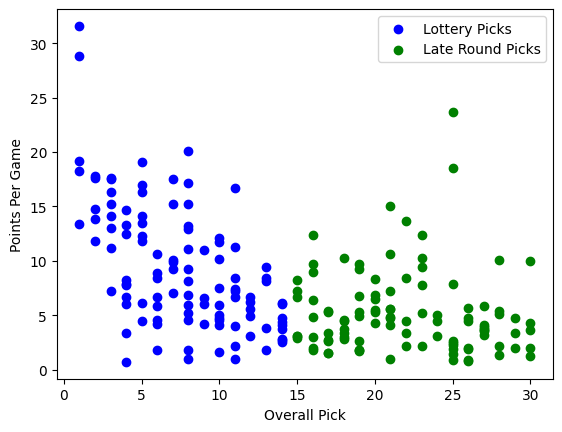

In [30]:
import matplotlib.pyplot as plt

lottery_sample[["overall_pick", "pts_per_game"]]
lateRd_sample[["overall_pick", "pts_per_game"]]

plt.scatter(lottery_sample["overall_pick"], lottery_sample["pts_per_game"], color="Blue", label="Lottery Picks")
plt.scatter(lateRd_sample["overall_pick"], lateRd_sample["pts_per_game"], color="Green", label="Late Round Picks")
plt.xlabel("Overall Pick")
plt.ylabel("Points Per Game")
plt.legend()
plt.show()


In [31]:
print(lottery_sample[lottery_sample["pts_per_game"] > 20])
print(lateRd_sample[lateRd_sample["pts_per_game"] > 20])

      draft_season  overall_pick             player_x team pos  pts_per_game
2908          1969           1.0  Kareem Abdul-Jabbar  MIL   C          28.8
2139          1982           8.0        Clark Kellogg  IND  PF          20.1
3252          1961           1.0         Walt Bellamy  CHP   C          31.6
      draft_season  overall_pick   player_x team pos  pts_per_game
3123          1967          25.0  Bob Verga  DLC  SG          23.7


## Box Plot Comparison

/var/folders/_l/z98hgdt92735rvlbttvfr81c0000gn/T/ipykernel_19125/1653521520.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


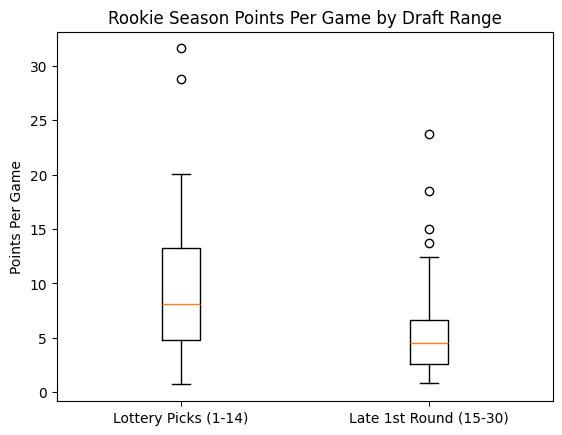

In [32]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.boxplot(
    [lottery_sample["pts_per_game"].dropna(), lateRd_sample["pts_per_game"].dropna()],
    labels=["Lottery Picks (1-14)", "Late 1st Round (15-30)"]
)
ax.set_ylabel("Points Per Game")
ax.set_title("Rookie Season Points Per Game by Draft Range")
plt.show()


## Histogram: Distribution of Points Per Game

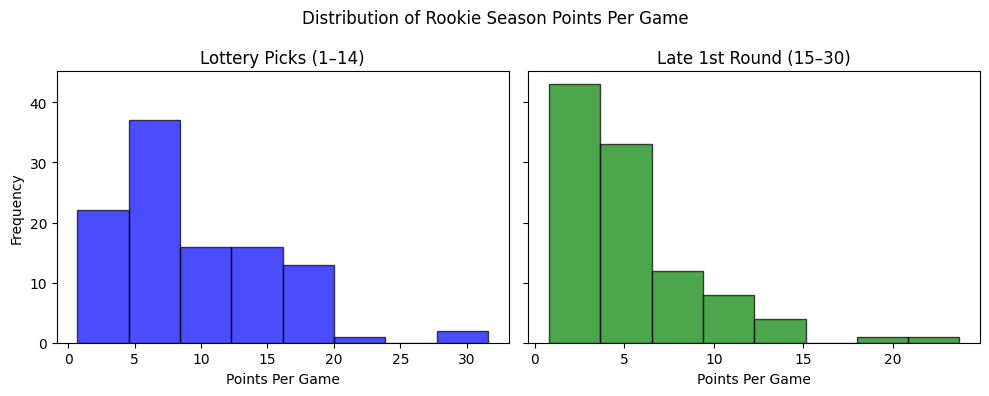

In [33]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 4))

axes[0].hist(lottery_sample["pts_per_game"].dropna(), bins=8, color="blue", edgecolor="black", alpha=0.7)
axes[0].set_title("Lottery Picks (1–14)")
axes[0].set_xlabel("Points Per Game")
axes[0].set_ylabel("Frequency")

axes[1].hist(lateRd_sample["pts_per_game"].dropna(), bins=8, color="green", edgecolor="black", alpha=0.7)
axes[1].set_title("Late 1st Round (15–30)")
axes[1].set_xlabel("Points Per Game")

plt.suptitle("Distribution of Rookie Season Points Per Game")
plt.tight_layout()
plt.show()


## Bar Chart: Average Points Per Game by Position

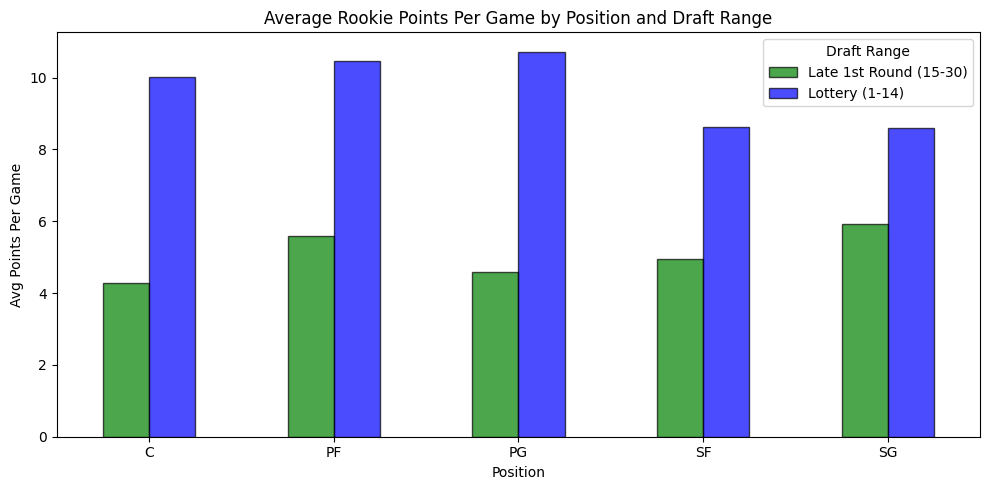

In [36]:
combined_sample = pd.concat([
    lottery_sample.assign(group="Lottery (1-14)"),
    lateRd_sample.assign(group="Late 1st Round (15-30)")
])

pos_avg = combined_sample.groupby(["pos", "group"])["pts_per_game"].mean().unstack(fill_value=0)

pos_avg.plot(kind="bar", figsize=(10, 5), color=["green", "blue"], edgecolor="black", alpha=0.7)
plt.xlabel("Position")
plt.ylabel("Avg Points Per Game")
plt.title("Average Rookie Points Per Game by Position and Draft Range")
plt.xticks(rotation=0)
plt.legend(title="Draft Range")
plt.tight_layout()
plt.show()


## Scatter Plot with Regression Line: Pick vs Points Per Game

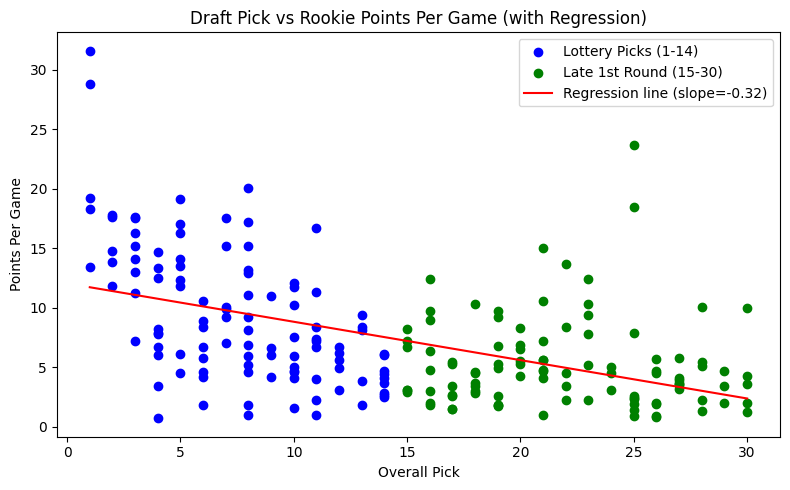

Regression equation: pts_per_game = -0.322 * pick + 12.042


In [35]:
import numpy as np

all_picks = combined_sample["overall_pick"].dropna()
all_pts = combined_sample.loc[all_picks.index, "pts_per_game"]

m, b = np.polyfit(all_picks, all_pts, 1)
x_line = np.linspace(all_picks.min(), all_picks.max(), 100)

plt.figure(figsize=(8, 5))
plt.scatter(lottery_sample["overall_pick"], lottery_sample["pts_per_game"], color="blue", label="Lottery Picks (1-14)")
plt.scatter(lateRd_sample["overall_pick"], lateRd_sample["pts_per_game"], color="green", label="Late 1st Round (15-30)")
plt.plot(x_line, m * x_line + b, color="red", label=f"Regression line (slope={m:.2f})")
plt.xlabel("Overall Pick")
plt.ylabel("Points Per Game")
plt.title("Draft Pick vs Rookie Points Per Game (with Regression)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Regression equation: pts_per_game = {m:.3f} * pick + {b:.3f}")


## T-Test for 2 Populations

In [44]:
from scipy import stats

res = stats.ttest_ind(lottery_sample["pts_per_game"], lateRd_sample["pts_per_game"], equal_var=False)

ci = res.confidence_interval(confidence_level=0.95)

print(f"T-statistic: {res.statistic:.9f}")
print(f"P-value: {res.pvalue:.9f}")
print(f"95% CI for the difference: {ci.low:.3f} to {ci.high:.3f}")

T-statistic: 6.155353271
P-value: 0.000000005
95% CI for the difference: 2.826 to 5.491
